# jaxfne — Étude No. 5 · Enhanced Biophysical Cortical Column

A single cortical column with **biologically-graded biophysics**, built natively by
`build_laminar_column(ei_profile="canonical")`. Everything is parametrized so the
same notebook scales from a 200-neuron demo to a 10,000-neuron column, with
**arbitrary cell-type composition per layer** and **arbitrary cell/connectivity
parameters**.

**What this column embodies (all applied at `construct` time):**
1. **SST fastness** `a=0.05`, intermediate between E (0.02, slow) and PV (0.10, fast).
2. **Deep-E "larger"** grading by depth Z: `source_scale 1.0→1.8`, `a 0.020→0.015`
   (slower), `d 8→10` (wider/stronger). Larger deep pyramidals fire sparser/slower.
3. **Random `v0` ~ U(−70, 0) mV** per neuron (always; seeded) — removes the
   onset-response synchrony bias that identical initial potentials create.
4. **Canonical per-layer composition** (`FRACS_LAYER`): inhibition-heavy superficial
   (L1/L2/L3 ≈ 50% I, L1 VIP-rich), E-dominated deep (L6 ≈ 95% E).
5. **PV↔E ×3 local** (distance-gated) — strengthened fast feedback-inhibition (PING).
6. **Size-aware homeostasis** (optional): per-neuron `k_gain ∝ 1/size`.

> Truth status: this is a **computational scaffold**. Field/probe outputs are
> `*_proxy` readouts (not calibrated physical signals); all truth gates stay at
> conservative defaults.

> **Tensor-first alternative:** this notebook defines its circuit via `Configuration` (the original fluent builder). As of 0.4.7, `NeuronalTensor` + `RuntimeConfiguration` is the preferred way to declare a multi-layer/multi-area circuit like this one -- see [`jaxfne_neuronal_tensor_first.ipynb`](../jaxfne_neuronal_tensor_first.ipynb), the [migration guide](../../docs/migration_guide.md), and the [NeuronalTensor API reference](../../docs/api/neuronal_tensor.md). `Configuration` remains fully supported; nothing below needs to change.

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jaxfne as jtfne
print("jaxfne", jtfne.__version__)

jaxfne 0.4.0


## 1 · Parameters — *edit anything here*

`N_TOTAL` controls the whole column (set to `10_000` for a full-resolution run).
`FRACS_LAYER` is the per-layer cell-type composition — change any fraction, add or
remove cell types, or supply your own layer set.

In [2]:
# ---- size & timing -------------------------------------------------------
N_TOTAL    = 300        # total neurons (scale freely, e.g. 1_000 or 10_000)
DURATION_MS = 2000.0
DT_MS       = 0.5
SEED        = 0

# ---- laminar structure ---------------------------------------------------
LAYERS = ["L1", "L2", "L3", "L4", "L5", "L6"]

# Per-layer cell-type fractions (arbitrary — must sum to 1.0 per layer).
FRACS_LAYER = {
    "L1": {"E": .50, "PV": .05, "SST": .10, "VIP": .35},
    "L2": {"E": .50, "PV": .25, "SST": .10, "VIP": .15},
    "L3": {"E": .50, "PV": .25, "SST": .15, "VIP": .10},
    "L4": {"E": .70, "PV": .20, "SST": .05, "VIP": .05},
    "L5": {"E": .85, "PV": .05, "SST": .05, "VIP": .05},
    "L6": {"E": .95, "PV": .00, "SST": .05, "VIP": .00},
}

# Relative depth band (z0, z1) per layer — band width sets the per-layer count.
Z_BANDS = {"L1": (0.00, 0.08), "L2": (0.08, 0.20), "L3": (0.20, 0.38),
           "L4": (0.38, 0.50), "L5": (0.50, 0.75), "L6": (0.75, 1.00)}

WITHIN_GAIN = 0.45      # within-column connectivity gain
for L, f in FRACS_LAYER.items():
    assert abs(sum(f.values()) - 1.0) < 1e-9, f"{L} fractions must sum to 1.0"
print(f"N_TOTAL={N_TOTAL}  layers={LAYERS}")

N_TOTAL=300  layers=['L1', 'L2', 'L3', 'L4', 'L5', 'L6']


## 2 · Build the column

`ei_profile="canonical"` triggers the integrated biophysics (deep-E grading, PV↔E
×3, random v0). Passing `layer_cell_type_fractions=FRACS_LAYER` makes the
composition fully explicit.

In [3]:
cfg = (
    jtfne.build_laminar_column(
        name="V1", n=N_TOTAL, layers=LAYERS,
        layer_fractions=Z_BANDS,
        layer_cell_type_fractions=FRACS_LAYER,
        ei_profile="canonical",            # applies canonical biophysics at construct
        within_gain=WITHIN_GAIN,
    )
    .runtime(seed=SEED)
    .set_emitter("izhikevich", "cortical_eig")
    .probes(["spikes", "V_m", "LFP", "CSD"], n_contacts=16)
    .field(domain="laminar_column", conductivity="proxy", boundary="mean_zero_neumann")
)
model = jtfne.construct(cfg)
emitter = model.params["emitter"]
N = int(emitter.v0.shape[0])
print(f"built model: N={N} neurons")
print("v0 randomized:", bool(np.asarray(emitter.v0).std() > 1.0),
      "| source_scale graded:", np.asarray(emitter.source_scale).ndim == 1)

built model: N=300 neurons
v0 randomized: True | source_scale graded: True


## 3 · Composition check — counts per layer × cell type

In [4]:
import collections
labels = np.array(emitter.labels); layers = np.array(emitter.layer_labels)
by_layer = collections.defaultdict(collections.Counter)
for l, ct in zip(layers, labels):
    by_layer[l][ct] += 1
print(f"{'layer':6} {'E':>4} {'PV':>4} {'SST':>4} {'VIP':>4}  {'tot':>4} {'I%':>4}")
for L in LAYERS:
    c = by_layer[L]; tot = sum(c.values())
    if not tot: continue
    ip = 100 * (tot - c["E"]) / tot
    print(f"{L:6} {c['E']:>4} {c['PV']:>4} {c['SST']:>4} {c['VIP']:>4}  {tot:>4} {ip:>3.0f}%")
ei = (labels == "E").mean()
print(f"\noverall  E:I = {ei*100:.0f}:{(1-ei)*100:.0f}")

layer     E   PV  SST  VIP   tot   I%
L1       12    1    2    9    24  50%
L2       18    9    4    5    36  50%
L3       27   14    8    5    54  50%
L4       25    7    2    2    36  31%
L5       64    4    4    3    75  15%
L6       71    0    4    0    75   5%

overall  E:I = 72:28


## 4 · Interactive 3D network (Plotly → HTML)

`vis.visualize_network_3d` returns a Plotly figure and writes a standalone
interactive HTML you can pan/zoom/rotate. Neurons are colored by cell type and
placed by their (x, y, depth-Z) coordinates.

In [5]:
from pathlib import Path
assets = Path("assets"); assets.mkdir(exist_ok=True)
html_path = assets / "etude5_network_3d.html"
fig3d = jtfne.vis.visualize_network_3d(
    model.neuron_table(),
    title=f"Étude 5 — {N}-neuron canonical column",
    show_layers=True, show_edges=False,
    output_html=str(html_path),
)
print("interactive 3D network saved ->", html_path)
fig3d  # renders inline in Jupyter

interactive 3D network saved -> assets/etude5_network_3d.html


## 5 · Simulate + depth-ordered raster

mean rate = 10.4 Hz   kappa = 0.017   Vm finite = True


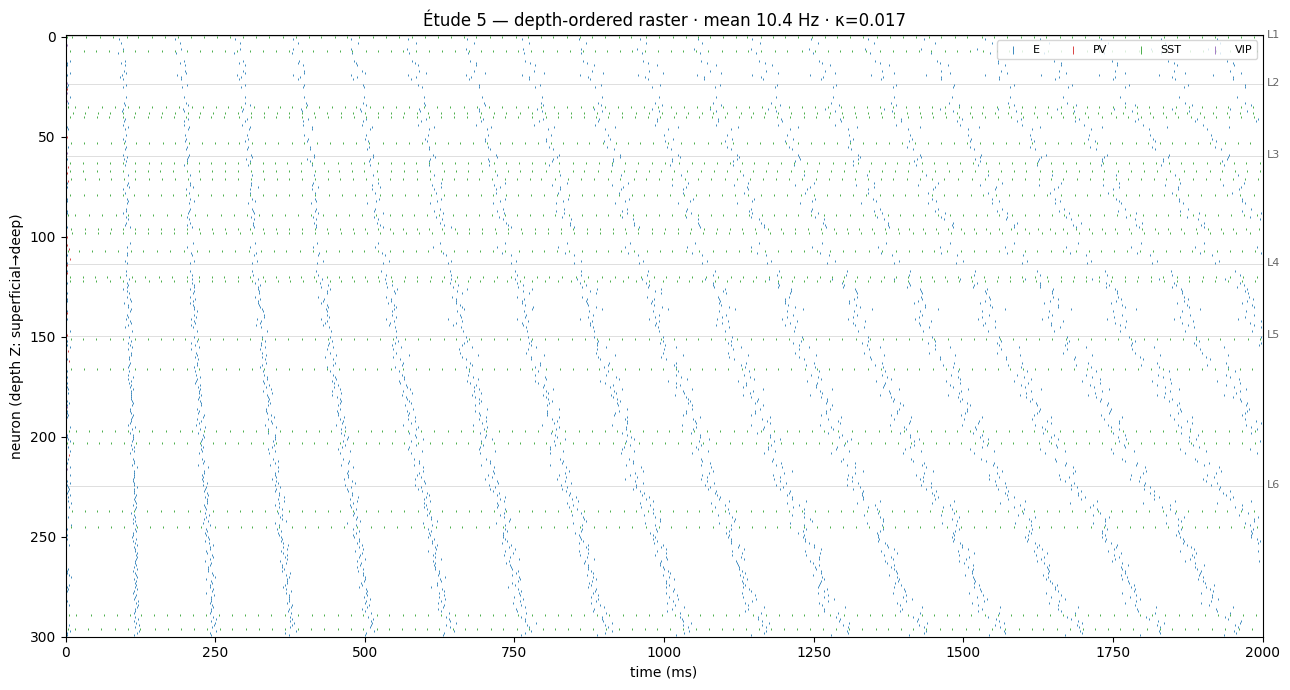

In [6]:
sig = jtfne.simulate(
    model,
    sim=jtfne.Simulation(duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED,
                         runtime=jtfne.RuntimeConfig(recurrent_backend="edge_list")),
)
spikes = np.asarray(sig.spikes); rate = spikes.sum(0) / (DURATION_MS / 1000.0)
kappa = float(jtfne.kappa_synchrony(sig.spikes, DT_MS))
print(f"mean rate = {rate.mean():.1f} Hz   kappa = {kappa:.3f}   "
      f"Vm finite = {bool(np.isfinite(np.asarray(sig.V_m)).all())}")

Z = np.asarray(model.params["positions"])[:, 2]
order = np.argsort(Z); rank = {n: i for i, n in enumerate(order)}
cmap = {"E": "#1f77b4", "PV": "#d62728", "SST": "#2ca02c", "VIP": "#9467bd"}
ti, ni = np.nonzero(spikes); y = np.array([rank[n] for n in ni]); t = ti * DT_MS
fig, ax = plt.subplots(figsize=(13, 7))
for ct, c in cmap.items():
    m_ = labels[ni] == ct
    ax.scatter(t[m_], y[m_], s=2.5, c=c, marker="|", linewidths=0.6, label=ct)
ls = layers[order]; prev = None
for i, L in enumerate(ls):
    if L != prev:
        ax.axhline(i - 0.5, color="0.85", lw=0.6, zorder=0)
        ax.text(DURATION_MS * 1.004, i + 0.5, L, fontsize=8, color="0.4"); prev = L
ax.set_xlim(0, DURATION_MS); ax.set_ylim(-1, N); ax.invert_yaxis()
ax.set_xlabel("time (ms)"); ax.set_ylabel("neuron (depth Z: superficial→deep)")
ax.set_title(f"Étude 5 — depth-ordered raster · mean {rate.mean():.1f} Hz · κ={kappa:.3f}")
ax.legend(loc="upper right", markerscale=4, fontsize=8, ncol=4)
plt.tight_layout(); plt.savefig(assets / "etude5_raster.png", dpi=130, bbox_inches="tight")
plt.show()

## 6 · Size-aware homeostasis (optional)

Enable the per-neuron intrinsic homeostatic controller with **`k_gain ∝ 1/size`**
so larger (deep-E) neurons are taxed less. `k_gain=0` is the null; the default
`k_gain=1.0` is a gentle in-band nudge.

In [7]:
rt_h = jtfne.RuntimeConfig(
    enable_homeostasis=True,
    homeostasis_params={"k_gain": 1.0, "k_gain_size_scaled": True},
)
sig_h = jtfne.simulate(model, sim=jtfne.Simulation(
    duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED, runtime=rt_h))
rate_h = np.asarray(sig_h.spikes).sum(0) / (DURATION_MS / 1000.0)
kappa_h = float(jtfne.kappa_synchrony(sig_h.spikes, DT_MS))
print(f"homeostasis OFF : mean {rate.mean():.1f} Hz · κ={kappa:.3f}")
print(f"homeostasis ON  : mean {rate_h.mean():.1f} Hz · κ={kappa_h:.3f}")
diag = model.last_homeostasis_diagnostics()
g = np.asarray(diag["g_bias"]); r = np.asarray(diag["r_trace"])
print(f"g_bias range [{g.min():.2f}, {g.max():.2f}] · r_trace range [{r.min():.3f}, {r.max():.3f}]")

homeostasis OFF : mean 10.4 Hz · κ=0.017
homeostasis ON  : mean 8.9 Hz · κ=0.019
g_bias range [-0.95, 0.00] · r_trace range [0.050, 1.000]


## 6 · Spectrolaminar suite (standard readout)

`jtfne.vis.spectrolaminar_suite_3panel(model, ...)` is the **standard laminar
readout**. Given a constructed model it runs `n_trials` simulations internally,
builds the depth × frequency relative-power profile, and renders four panels:
superficial-vs-deep spectra, the depth×freq heatmap, the **α/β (deep) vs γ
(superficial) crossover**, and firing-rate-by-depth. Proxy readout (`*_proxy`).

> The deep-α/β vs superficial-γ crossover is **scale- and oscillation-emergent**;
> at small N / asynchronous-irregular regimes it is weak. Keep κ low and scale N up
> (and/or add band-limited drive) to bring it out.

saved assets/etude5_spectrolaminar_V1.png


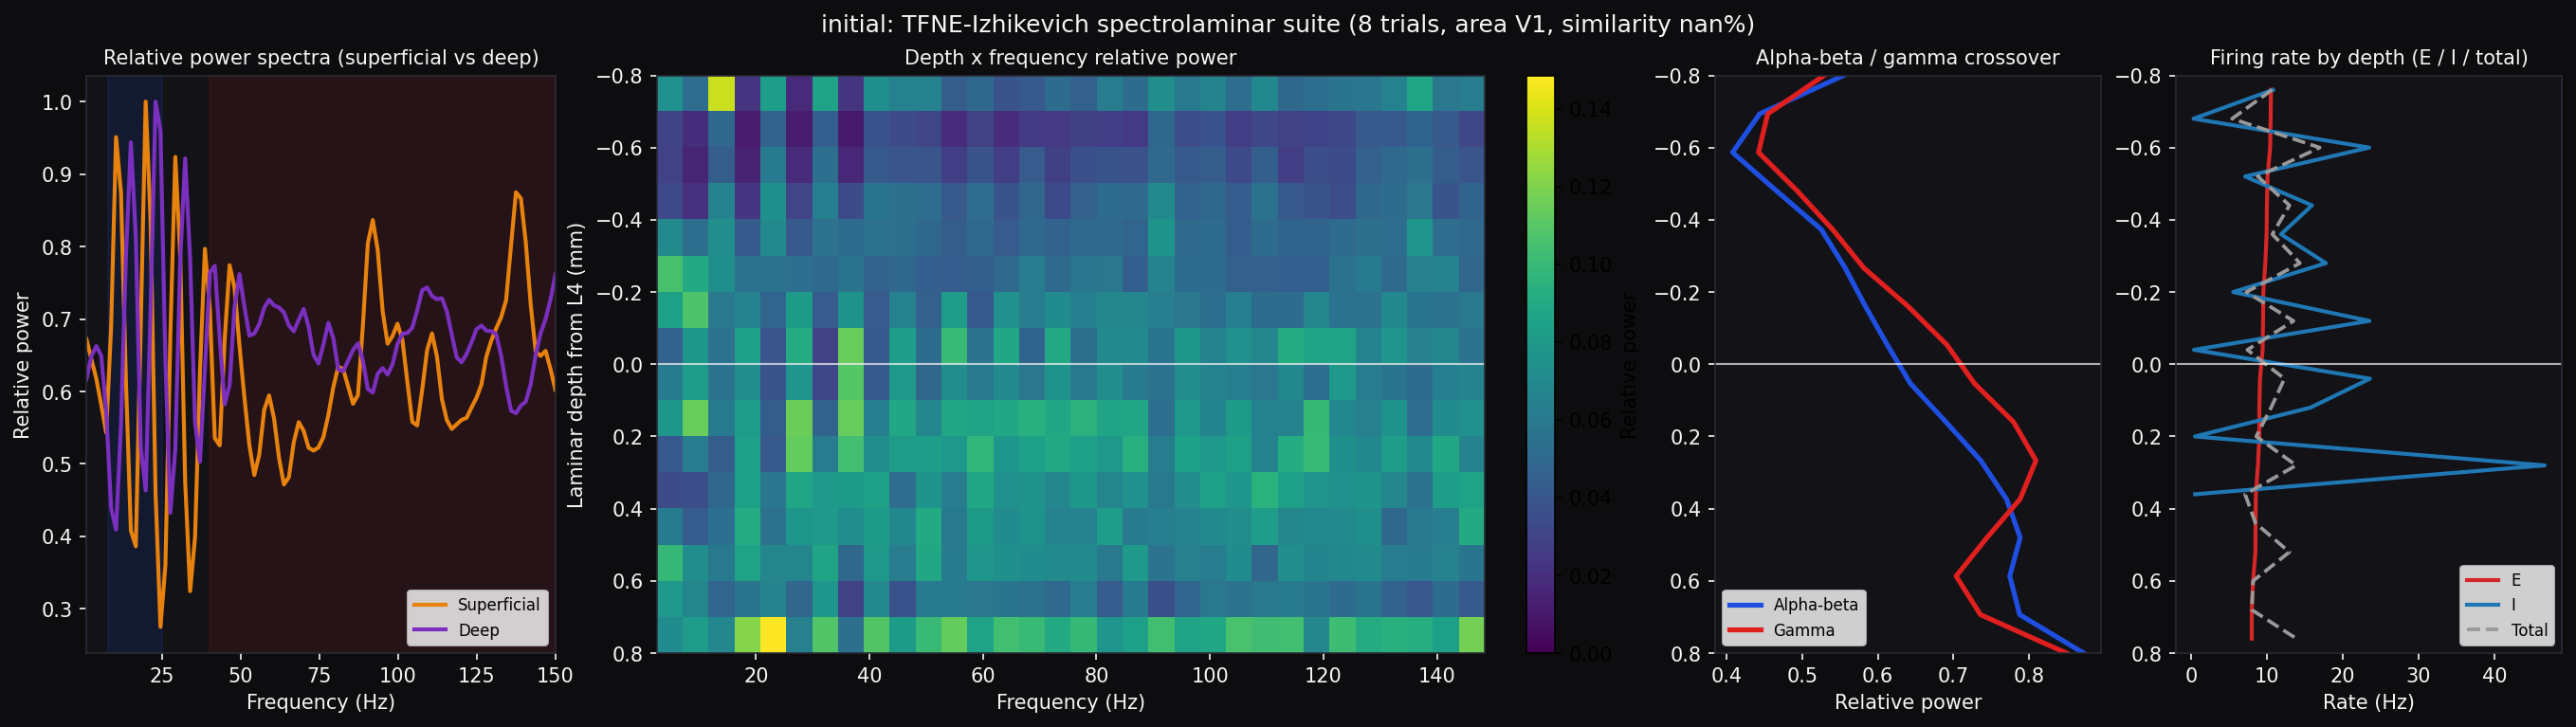

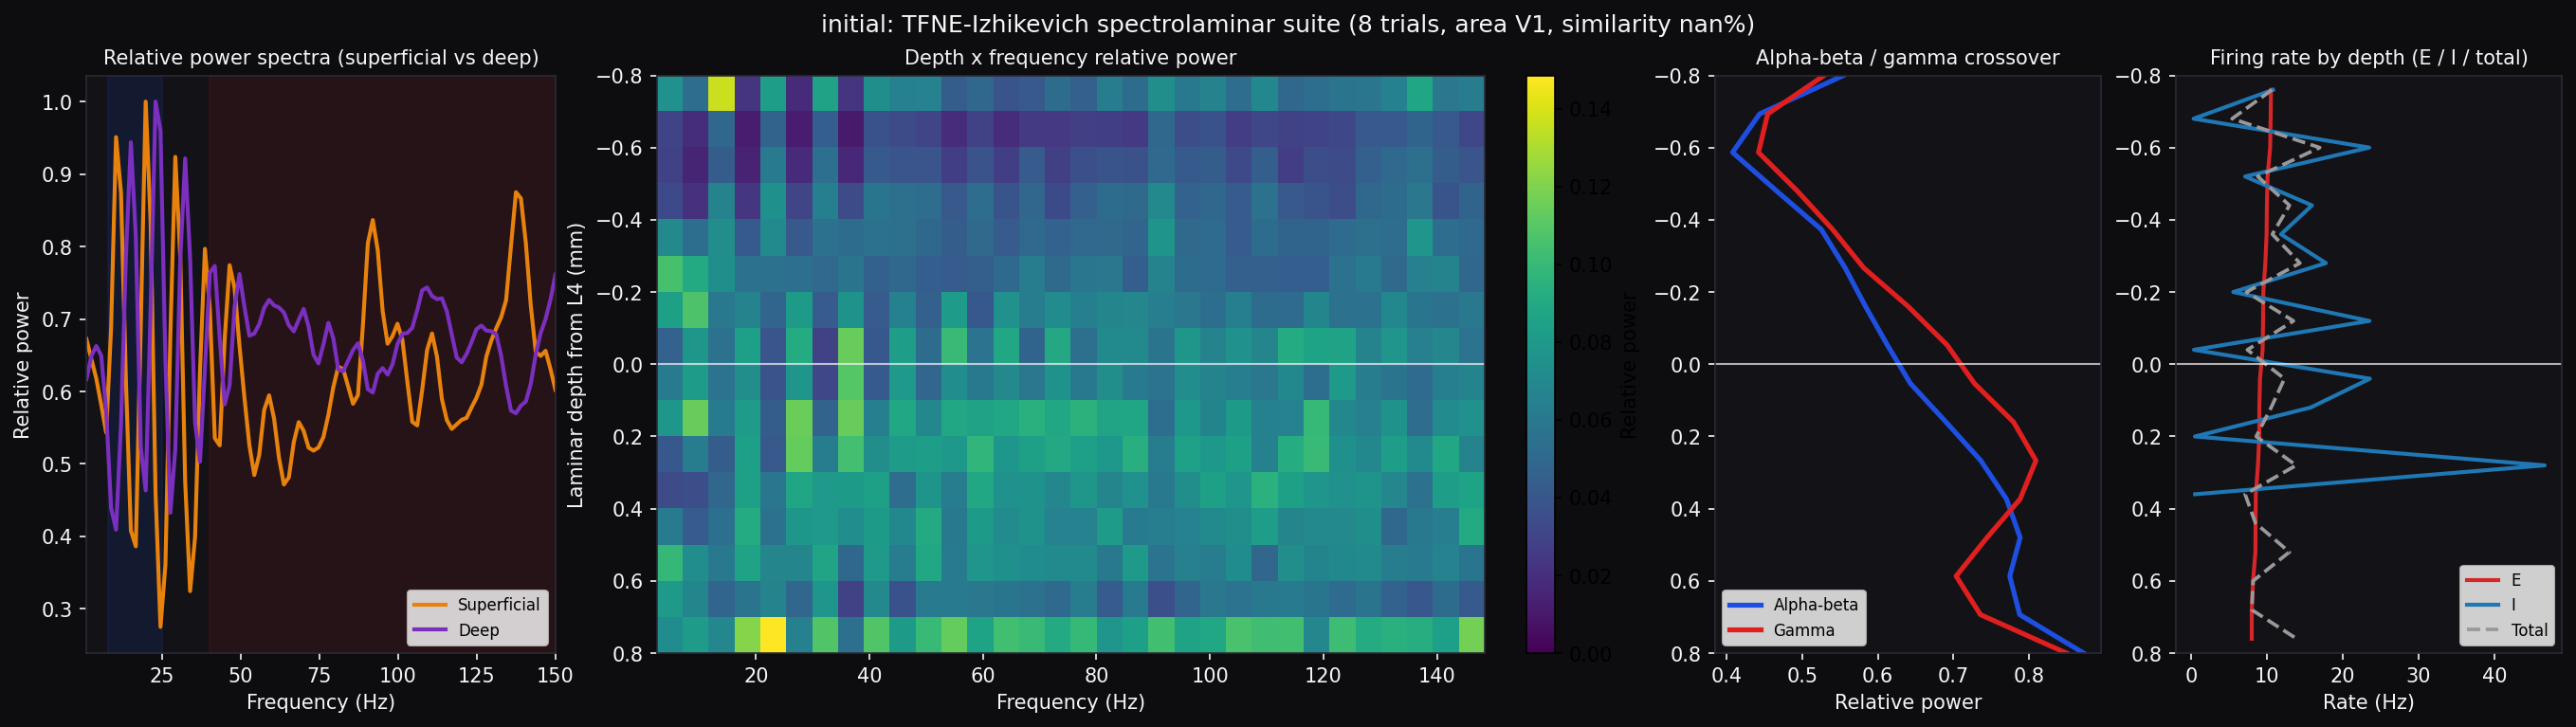

In [8]:
specfigs = jtfne.vis.spectrolaminar_suite_3panel(
    model, n_trials=8, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED,
    signal="csd", freq_min_hz=1.0, freq_max_hz=150.0, freq_count=96,
)
for area, f in specfigs.items():
    out = assets / f"etude5_spectrolaminar_{area}.png"
    f.savefig(out, dpi=130, bbox_inches="tight")
    print("saved", out)
list(specfigs.values())[0]  # render first area inline

## 7 · Notes

- **Scaling:** raise `N_TOTAL` (e.g. `10_000`). Build/sim cost grows with N; reuse the
  built `model` across seeds/durations rather than rebuilding (only rebuild when
  *structure* changes).
- **Arbitrary composition:** edit `FRACS_LAYER` / `LAYERS` / `Z_BANDS` freely; for
  per-cell-type parameter overrides use `cfg.cell_params({"cell_type": ...}, {...})`.
- **Synchrony:** keep κ low (≈< 0.1) for trustworthy laminar/spectrolaminar readouts.
- **Artifacts:** interactive 3D network → `assets/etude5_network_3d.html`; raster →
  `assets/etude5_raster.png`.
- **Truth:** computational scaffold; `*_proxy` readouts only; gates unchanged
  (`claim_level=computational_scaffold`, `physical_amplitude_calibrated=False`).

*Next: Étude No. 6 connects multiple of these columns into a multi-area network.*